In [1]:
import os
import numpy as np
import pandas as pd
import librosa

In [54]:
music_df = pd.read_csv('/content/drive/MyDrive/start-10/DEAM/deam_av.csv')
music_df.head()

,energy,loudness,tempo,key,mode,time_signature,song_id,valence_mean,arousal_mean
0,0.012146,-21.465645,[139.67483108],9,1,[1.00103066],2.0,3.1,3.0
1,0.017426,-25.533651,[95.703125],4,1,[0.98865395],3.0,3.5,3.3
2,0.039658,-18.046253,[112.34714674],9,1,[1.00825168],4.0,5.7,5.5
3,0.024600,-20.400837,[123.046875],11,1,[1.01805054],5.0,4.4,5.3
4,0.074468,-19.637709,[120.18531977],4,1,[0.99716568],7.0,5.8,6.4


In [55]:
music_df['tempo'] = music_df['tempo'].apply(lambda x: float(x[1:-1]))
music_df['time_signature'] = music_df['time_signature'].apply(lambda x: float(x[1:-1]))

# data load

In [1]:
from google.colab import drive
import zipfile

# 파일 경로
zip_file_path_list = [
                 '/content/drive/MyDrive/start-10/DEAM/DEAM_Annotations.zip',
                 '/content/drive/MyDrive/start-10/DEAM/DEAM_audio.zip'
                 ]

# 압축 해제
for zip_file_path in zip_file_path_list:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
      zip_ref.extractall('/content/DEAM')

print(f"{zip_file_path} 압축 해제 완료!")

KeyboardInterrupt: 

In [ ]:
# 오디오 파일 디렉토리 경로
audio_dir = '/content/DEAM/MEMD_audio/'

# 주석 파일 로드 및 병합
annotations1 = pd.read_csv('/content/DEAM/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv')
annotations2 = pd.read_csv('/content/DEAM/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv')
annotations = pd.concat([annotations1, annotations2], ignore_index=True)

In [ ]:
annotations

,song_id,valence_mean,valence_std,arousal_mean,arousal_std,valence_ max_mean,valence_max_std,valence_min_mean,valence_min_std,arousal_max_mean,arousal_max_std,arousal_min_mean,arousal_min_std
0,2,3.10,0.94,3.00,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,3.50,1.75,3.30,1.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,5.70,1.42,5.50,1.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,4.40,2.01,5.30,1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,5.80,1.47,6.40,1.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797,2054,5.40,1.20,3.60,1.36,6.0,1.10,4.40,1.36,4.20,1.33,2.40,0.80
1798,2055,5.00,1.41,5.20,1.47,6.0,1.41,4.20,1.33,6.40,1.62,4.00,1.41
1799,2056,5.00,1.41,4.60,1.74,5.6,1.62,4.40,1.36,5.00,1.79,4.00,1.67
1800,2057,3.17,1.07,6.83,0.37,4.5,0.76,2.17,0.90,8.17,0.90,4.83,1.46


# audio feaures extraction

In [ ]:
import librosa
import numpy as np

def extract_audio_features(file_path):
    # 오디오 파일 로드
    y, sr = librosa.load(file_path, sr=None)

    # 에너지 계산
    energy = np.sum(y**2) / len(y)

    # 음량(Loudness) 계산
    S = np.abs(librosa.stft(y))
    loudness = np.mean(librosa.amplitude_to_db(S))

    # 템포(Tempo) 추정
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # 키(Key) 및 모드(Mode) 추정
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    key = np.argmax(np.mean(chroma, axis=1))
    mode = 1 if np.mean(chroma[key]) > np.mean(chroma[(key + 3) % 12]) else 0 # major(1), minor(0)

    # 박자(Time Signature) 추정
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    times = librosa.times_like(onset_env, sr=sr)
    tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
    beat_times = librosa.frames_to_time(beats, sr=sr)
    time_signature = len(beat_times) / (times[-1] / 60) / tempo

    return {
        'energy': energy,
        'loudness': loudness,
        'tempo': tempo,
        'key': key,
        'mode': mode,
        'time_signature': time_signature
    }

In [ ]:
features = []

for idx, row in annotations.iterrows():
    song_id = row['song_id']
    file_path = os.path.join(audio_dir, f'{int(song_id)}.mp3')

    if os.path.exists(file_path):
        audio_features = extract_audio_features(file_path)
        audio_features.update({
            'song_id': song_id,
            'valence_mean': row['valence_mean'],
            'arousal_mean': row['arousal_mean']
        })
        features.append(audio_features)
    else:
        print(f'파일 {file_path}을 찾을 수 없습니다.')

# 데이터프레임 생성
music_df = pd.DataFrame(features)

In [ ]:
#music_df.to_csv('music_av.csv')

In [ ]:
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,valence_mean,arousal_mean
0,0.012146,-21.465645,[139.6748310810811],9,1,[1.0010306622004637],2.0,3.10,3.00
1,0.017426,-25.533651,[95.703125],4,1,[0.9886539453326456],3.0,3.50,3.30
2,0.039658,-18.046253,[112.34714673913044],9,1,[1.0082516761217122],4.0,5.70,5.50
3,0.024600,-20.400837,[123.046875],11,1,[1.0180505415162455],5.0,4.40,5.30
4,0.074468,-19.637709,[120.18531976744185],4,1,[0.9971656789487247],7.0,5.80,6.40
...,...,...,...,...,...,...,...,...,...
1797,0.015683,-29.476341,[178.20581896551724],11,1,[0.9725394896719318],2054.0,5.40,3.60
1798,0.030940,-15.287614,[123.046875],9,1,[1.0049901832460733],2055.0,5.00,5.20
1799,0.008828,-25.813923,[99.38401442307692],4,1,[0.9739442946990117],2056.0,5.00,4.60
1800,0.033607,-13.712579,[126.04801829268293],11,1,[0.9909915625198249],2057.0,3.17,6.83


array([[<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'time_signature'}>],
       [<Axes: title={'center': 'song_id'}>,
        <Axes: title={'center': 'valence_mean'}>,
        <Axes: title={'center': 'arousal_mean'}>]], dtype=object)

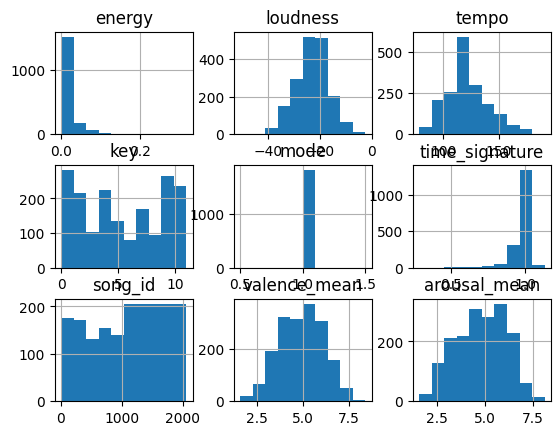

In [ ]:
music_df.hist()

In [ ]:
music_df['tempo'] = music_df['tempo'].apply(lambda x: x[0] if len(x) == 1 else x)
music_df['time_signature'] = music_df['time_signature'].apply(lambda x: x[0] if len(x) == 1 else x)

In [ ]:
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,valence_mean,arousal_mean
0,0.012146,-21.465645,139.674831,9,1,1.001031,2.0,3.10,3.00
1,0.017426,-25.533651,95.703125,4,1,0.988654,3.0,3.50,3.30
2,0.039658,-18.046253,112.347147,9,1,1.008252,4.0,5.70,5.50
3,0.024600,-20.400837,123.046875,11,1,1.018051,5.0,4.40,5.30
4,0.074468,-19.637709,120.185320,4,1,0.997166,7.0,5.80,6.40
...,...,...,...,...,...,...,...,...,...
1797,0.015683,-29.476341,178.205819,11,1,0.972539,2054.0,5.40,3.60
1798,0.030940,-15.287614,123.046875,9,1,1.004990,2055.0,5.00,5.20
1799,0.008828,-25.813923,99.384014,4,1,0.973944,2056.0,5.00,4.60
1800,0.033607,-13.712579,126.048018,11,1,0.990992,2057.0,3.17,6.83


# regression model

## 다변량 회귀

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# 독립 변수 (features)
X = music_df[['energy', 'loudness', 'tempo', 'key', 'time_signature']]

# 종속 변수 (targets)
y = music_df[['valence_mean', 'arousal_mean']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 모델 생성
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 예측 수행
y_pred = model.predict(X_test)

# 평가 지표 계산
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 1.01076826268576
R^2 Score: 0.28089915088578193


## 신경망

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

In [58]:
# 독립 변수와 종속 변수 정의
X = music_df[['energy', 'loudness', 'tempo', 'key', 'time_signature']].values
y = music_df[['valence_mean', 'arousal_mean']].values

# 데이터 분할: 80% 학습용, 20% 검증용
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 텐서 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# 데이터로더
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [71]:
class MultivariateRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim=2):
        super(MultivariateRegressionModel, self).__init__()

        self.model = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(32),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# loss function
def loss_fn(y_pred, y_true):
    # 각 출력에 대한 MSE 계산
    mse = nn.MSELoss(reduction='none')
    loss = mse(y_pred, y_true)
    # 각 출력의 손실 반환
    return loss.mean(dim=0)

In [81]:
input_dim = X_train_tensor.shape[1]
model = MultivariateRegressionModel(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 파라미터 설정
epochs = 30
train_loss_v = []
train_loss_a = []
val_loss_v = []
val_loss_a = []

# 훈련 루프
model.train()
for epoch in range(epochs):
    total_train_loss = torch.zeros(2)
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.sum().backward()
        optimizer.step()
        total_train_loss += loss.detach()
    avg_train_loss = total_train_loss / len(train_loader)

    # 검증 루프
    model.eval()
    with torch.no_grad():
        total_val_loss = torch.zeros(2)
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_val_loss += loss
        avg_val_loss = total_val_loss / len(val_loader)

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {avg_train_loss[0].item():.4f}, {avg_train_loss[1].item():.4f}, '
          f'Val Loss: {avg_val_loss[0].item():.4f}, {avg_val_loss[1].item():.4f}')

    train_loss_v.append(avg_train_loss[0].item())
    train_loss_a.append(avg_train_loss[1].item())
    val_loss_v.append(avg_val_loss[0].item())
    val_loss_a.append(avg_val_loss[1].item())

Epoch [1/30], Train Loss: 26.8667, 23.9383, Val Loss: 24.4925, 21.2800
Epoch [2/30], Train Loss: 19.7097, 16.5989, Val Loss: 11.9839, 9.0255
Epoch [3/30], Train Loss: 5.9474, 4.4407, Val Loss: 2.6328, 1.6393
Epoch [4/30], Train Loss: 1.4702, 1.3067, Val Loss: 1.1990, 1.0723
Epoch [5/30], Train Loss: 0.9444, 1.0839, Val Loss: 1.0880, 1.0036
Epoch [6/30], Train Loss: 0.8996, 1.0370, Val Loss: 1.0789, 0.9861
Epoch [7/30], Train Loss: 0.8722, 1.0163, Val Loss: 1.0486, 0.9745
Epoch [8/30], Train Loss: 0.8606, 1.0183, Val Loss: 1.0329, 0.9674
Epoch [9/30], Train Loss: 0.8512, 1.0005, Val Loss: 1.0128, 0.9532
Epoch [10/30], Train Loss: 0.8469, 1.0023, Val Loss: 1.0239, 0.9626
Epoch [11/30], Train Loss: 0.8427, 0.9945, Val Loss: 1.0182, 0.9497
Epoch [12/30], Train Loss: 0.8260, 0.9783, Val Loss: 1.0199, 0.9521
Epoch [13/30], Train Loss: 0.8382, 0.9849, Val Loss: 1.0310, 0.9730
Epoch [14/30], Train Loss: 0.8226, 0.9874, Val Loss: 1.0468, 0.9931
Epoch [15/30], Train Loss: 0.8241, 0.9863, Val Los

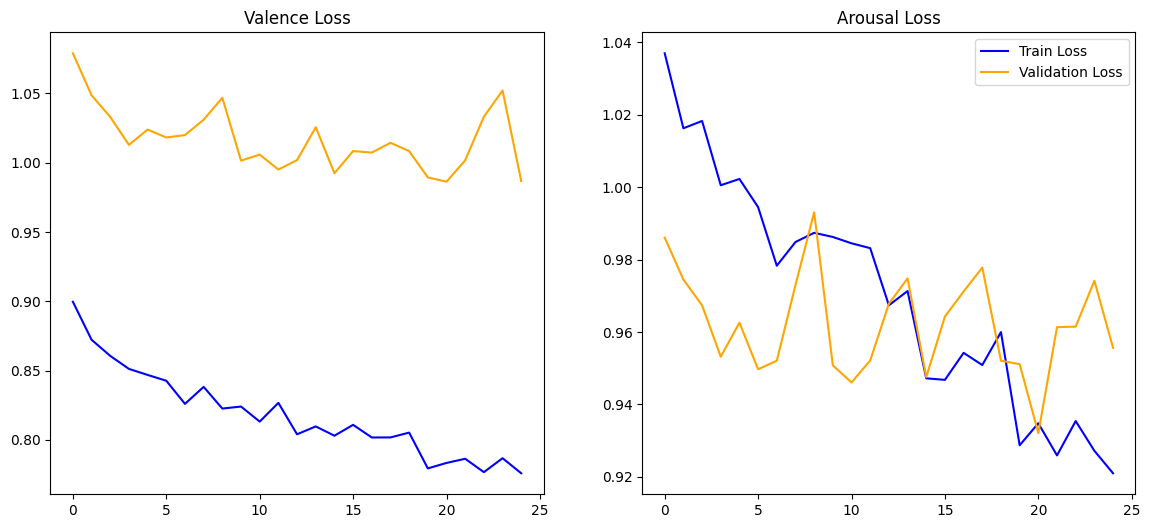

In [85]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].set_title('Valence Loss')
axs[0].plot(train_loss_v[5:], label='Train Loss', color='blue')
axs[0].plot(val_loss_v[5:], label='Validation Loss', color='orange')

axs[1].set_title('Arousal Loss')
axs[1].plot(train_loss_a[5:], label='Train Loss', color='blue')
axs[1].plot(val_loss_a[5:], label='Validation Loss', color='orange')
plt.legend()

In [86]:
# 테스트 데이터 예측
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_val_tensor)
    y_pred = y_pred_tensor.numpy()

# 평가 지표 계산
from sklearn.metrics import mean_squared_error, r2_score
y_test = y_val_tensor.numpy()
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred, multioutput='raw_values')

print(f'MSE for each output: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2 Score: {r2}')

MSE for each output: [0.9785938  0.95432955]
RMSE: [0.98923904 0.9768979 ]
R^2 Score: [0.26991218 0.35459483]


In [79]:
# 평균 계산
dummy_pred = torch.mean(y_train_tensor, dim=0).unsqueeze(0).expand(y_val_tensor.size(0), -1).cpu().numpy()

# 평가 지표 계산
dummy_mse = mean_squared_error(y_test, dummy_pred, multioutput='raw_values')
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(y_test, dummy_pred, multioutput='raw_values')

print(f'Dummy RMSE: {dummy_rmse}')
print(f'Dummy R^2 Score: {dummy_r2}')

Dummy RMSE: [1.1621872 1.2190019]
Dummy R^2 Score: [-0.00768507 -0.00494623]


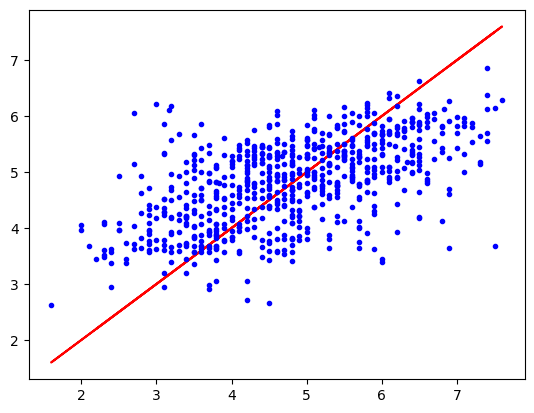

In [87]:
import matplotlib.pyplot as plt

plt.plot(y_test, y_test, 'r-')
plt.plot(y_test, y_pred, 'b.')